## Module_3:

## Team Members:
* Isabel Vikesland
* Karinna Fink

## Project Title:
*(Fill in)*



## Project Goal:
This project seeks to develop an image analysis pipeline that will predict the extent of fibrosis in the lung at different biopsy depths from the top of the lung. 

We will develop an algorithm that allows us to interpolate the amount of fibrosis at a specific depth, based on a sample data set.

## Disease Background: 
*Fill in information and please note that this module is truncated and only has 5 bullets (instead of the 11 that you did for Module #1).*

* Prevalence & incidence
* Risk factors (genetic, lifestyle)
* Symptoms
* Standard of care treatment(s)
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

## Data-Set: 
*Describe the data set(s) you will analyze. Cite the source(s) of the data -- in this case, these data have not yet been published and they are "hot off the press", having been recently generated by the Peirce-Cottler Lab in collaboration with the Kim Lab (https://uvahealth.com/findadoctor/John-Kim-1407155682) in the Division of Pulmonary and Critical Care at UVA. So the proper way to cite these data is:

"Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

Also, since we covered this in Lecture 1 of this Module in detail, describe how the data was collected -- What techniques were used? What units are the data measured in? Etc.*

- input images from biorender into explanation??
- image limitation from artifacts recognizing as fibrosis
- transverse sections of 10 micrometers from top to bottom of mouse lungs

*Notes about images : 
images/MASK_SK658 Llobe ch010019.jpg,60

images/MASK_SK658 Llobe ch010168.jpg,6000

images/MASK_SK658 Slobe ch010096.jpg,9400

images/MASK_SK658 Slobe ch010098.jpg,10000

images/MASK_SK658 Slobe ch010111.jpg,8600

images/MASK_SK658 Slobe ch010140.jpg,8300

## Data Analyis: 
*Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this Jupyter notebook can run your code to perform the analysis that you did, generate your figures, generate your .csv file, etc.). Show your graphs here, which should have proper labeles (e.g., x- and y-axes labels). Each graph you present should be thoroughly described by a caption so reader understands the data, why you are presenting it, and the main conclusion fromt the data.*



### Step 1: Initializing and importing

In [1]:
import cv2
import numpy as np
import pandas as pd
from termcolor import colored
import time
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd


graphed_files = [
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010019.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Llobe ch010168.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010096.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_Sk658 Slobe ch010098.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010111.jpg",
    "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/images/MASK_SK658 Slobe ch010140.jpg"
]
graphed_depths = [60, 6000, 3000, 9400, 10000, 8300]


### Step 2: Write and run a function that finds the percentage of the image taken up by white pixels ###

In [2]:
def get_white_pixels(csv_path, graphed_files): # two parameters: path to the csv file to be loaded into a dataframe and the files that you want actually graphed
    df = pd.read_csv(csv_path) # Read the csv file as a pandas dataframe
    results = []
    white_percents = []
    depths = []
    graphed_white_percents = []
    for i, row in df.iterrows():
        # Put the file path together
        file_beginning = "C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/"
        filename = file_beginning + row['Filenames']

        # add the image depth form the datafram into a list
        depth = row['Depth from lung surface (in micrometers) where image was acquired']
        depths.append(depth)

        # Load grayscale image
        img = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

        binary = img >= 127 # if the pixel value is at least 127, it is given the value of True (white) 

        # calculate the percentage of white pixels in the image
        white = np.sum(binary) # add how many values are true
        black = binary.size - white
        white_percent = 100 * white / (white + black)
        white_percents.append(white_percent)

        # for the files that are being graphed, add the percentage of white pixels to a list to be used for graphing
        if filename in graphed_files:
            graphed_white_percents.append(white_percent)
            #print(filename)

        results.append({"Filename": filename, "Depth": depth,"White Percent": white_percent})

        df2 = pd.DataFrame(results)
        df2.to_csv("Percent_White_Pixels.csv", index=False)

    print("The .csv file 'Percent_White_Pixels.csv' has been created.")
    return graphed_white_percents, depths, results, white_percents

graphed_white_percents, known_depths, results, white_percents = get_white_pixels('C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/Filenames and Depths for Students.csv', graphed_files)

The .csv file 'Percent_White_Pixels.csv' has been created.



### Step 3: Ask user how many points they would like to interpolate, and then ask the user what those points are

In [3]:
# ask user how many depths they would like to interpolate a point for 
number_depths = int(input(colored("Enter the number of depths at which you want to interpolate a point: ")))

interpolate_depths = []
counter = 0

while counter < number_depths: # iterates until the user has entered the number of depths they wanted to interpolate a point for

    depths_addition = float(input(colored("Enter the depth at which you want to interpolate a point (in microns): ", "yellow")))
    if (depths_addition > min(graphed_depths)) and (depths_addition < max(graphed_depths)): # checks that entered depth is within the range of known depths
        interpolate_depths.append(depths_addition) # add the depth to the list of depths to be interpolated
        counter += 1

    else:
        print(colored("Please enter a depth between 60 and 10000 microns.", 'red')) # ask user to re-enter a depth if it is outside the range of known depths

### Step 4: Interpolate white percentage and graph results

In [ ]:
x = graphed_depths
y = graphed_white_percents

#print(f"x: {x}")
#print(f"y: {y}")

# make copies of the known depths and white percentages to be used for interpolation
depths_i1 = graphed_depths[:]
white_percents_i1 = graphed_white_percents[:]
depths_i2 = graphed_depths[:]
white_percents_i2 = graphed_white_percents[:]

# linear interpolation
for i in range(number_depths):
    i1 = interp1d(x, y, kind = 'linear')
    interpolate_point1 = i1(interpolate_depths[i])
    depths_i1.append(interpolate_depths[i])
    white_percents_i1.append(interpolate_point1)

# quadratic interpolation
for i in range(number_depths):
    i2 = interp1d(x, y, kind = 'quadratic')
    interpolate_point2 = i2(interpolate_depths[i])
    depths_i2.append(interpolate_depths[i])
    white_percents_i2.append(interpolate_point2)


print("Linearly interpolated points: ")
for i in range(number_depths):
    print(f"Point {i+1}: ({depths_i1[-(i+1)]}, {white_percents_i1[-(i+1)]})")

print("Quadratically interpolated points: ")
for i in range(number_depths):
    print(f"Point {i+1}: ({depths_i2[-(i+1)]}, {white_percents_i2[-(i+1)]})")

Linearly interpolated points: 
Point 1: (8781.0, 6.714537728916515)
Point 2: (6549.0, 3.9856518973474917)
Point 3: (327.0, 0.981888552101291)
Quadratically interpolated points: 
Point 1: (8781.0, 6.700871672258953)
Point 2: (6549.0, 4.29520677596929)
Point 3: (327.0, 1.300585895123742)


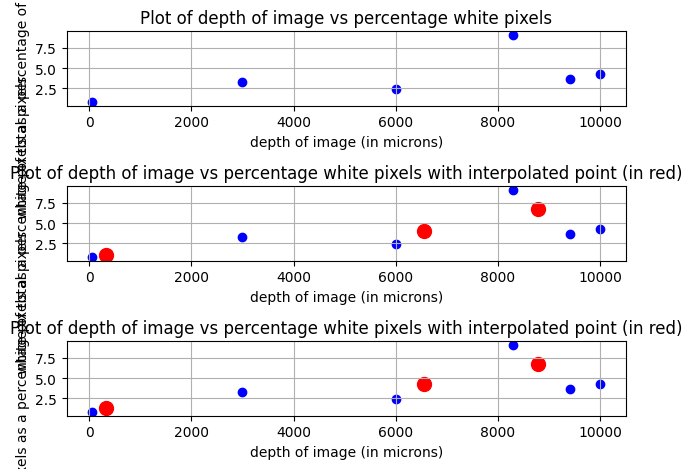

In [5]:
fig, axs = plt.subplots(3, 1) # make 3 plots

# plot without interpolated points
axs[0].scatter(graphed_depths, graphed_white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a percentage of total pixels')
axs[0].grid(True)

# plot with linearly interpolated points
axs[1].scatter(depths_i1, white_percents_i1, marker='o',linestyle='-', color='blue')
axs[1].set_title('Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a percentage of total pixels')
axs[1].grid(True)

for i in range(number_depths):
    axs[1].scatter(depths_i1[len(depths_i2)-(i+1)], white_percents_i1[len(white_percents_i2)-(i+1)], color='red', s=100, label='Highlighted point')

# plot for quadratically interpolated points
axs[2].scatter(depths_i2, white_percents_i2, marker='o',linestyle='-', color='blue')
axs[2].set_title('Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[2].set_xlabel('depth of image (in microns)')
axs[2].set_ylabel('white pixels as a percentage of total pixels')
axs[2].grid(True)

for i in range(number_depths):
    axs[2].scatter(depths_i2[len(depths_i1)-(i+1)], white_percents_i2[len(white_percents_i1)-(i+1)], color='red', s=100, label='Highlighted point')

plt.tight_layout()
plt.show()

In [ ]:
def find_closest_point(depths, white_percentages):
    new_depth = depths[-number_depths:]
    best_differences = []
    best_depths = []
    indices = []
    counter = 0

    # for each interpolated depth, find the closest known depth and calculate the difference in white pixel percentage between the interpolated point and the closest known point
    for depth in new_depth:
        difference = 1000000 # set depth to something way higher than it could possibly be
        best_depth = 0
        index = 0

        # import the csv file as a dataframe and iterate through the rows to find the closest known depth to the interpolated depth
        df = pd.read_csv('C:/Users/karin/OneDrive - University of Virginia/Second Year/Comp BME/Module-3-Fibrosis/Filenames and Depths for Students.csv')
        for i, row in df.iterrows(): #iterate over rows in the dataframe
            new_diff = abs(depth - row['Depth from lung surface (in micrometers) where image was acquired'])

            if new_diff < difference: # iterate through row to find the closest known depth to the interpolated depth
                difference = new_diff
                best_depth = row['Depth from lung surface (in micrometers) where image was acquired']
                index = i
        best_differences.append(difference)
        best_depths.append(best_depth)
        indices.append(index)
        
        subtraction = abs(white_percentages[-(counter + 1)] - white_percents[index])
        print(f"At depth {depth}, the interpolated white pixel percentage is {white_percentages[-(counter+1)]}. The closest known depth is {best_depth}, which is {difference} micrometers away. At that point, the percentage of white pixels is {white_percents[index]}%, which is {subtraction}% away from the interpolated value")
        counter += 1

    
    return best_depths, indices


print("\n For Linear Interpolation: ")
find_closest_point(depths_i1,white_percents_i1)
print("\n For Quadratic Interpolation: ")
find_closest_point(depths_i2,white_percents_i2)



 For Linear Interpolation: 
At depth 327.0, the interpolated white pixel percentage is 6.714537728916515. The closest known depth is 330, which is 3.0 micrometers away. At that point, the percentage of white pixels is 0.9076118469238281%, which is 5.8069258819926866% away from the interpolated value
At depth 6549.0, the interpolated white pixel percentage is 3.9856518973474917. The closest known depth is 6600, which is 51.0 micrometers away. At that point, the percentage of white pixels is 2.4147748947143555%, which is 1.5708770026331362% away from the interpolated value
At depth 8781.0, the interpolated white pixel percentage is 0.981888552101291. The closest known depth is 8800, which is 19.0 micrometers away. At that point, the percentage of white pixels is 3.6032676696777344%, which is 2.6213791175764434% away from the interpolated value

 For Quadratic Interpolation: 
At depth 327.0, the interpolated white pixel percentage is 6.700871672258953. The closest known depth is 330, whi

([330, 6600, 8800], [9, 43, 62])

## Verify and validate your analysis: 
*Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., by comparing your analysis to a published paper).*

## Conclusions and Ethical Implications: 
*Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*Describe the limitations of your project. If you had more time to work on this, what would you do to explore further or refine your analysis?*

- include: Mouse model is a good analysis but NOT a great one

## References:
*You can use any format you like but provide the citations for facts that you referenced in this project notebook.*